# Data preprocessing + ViT baseline

This notebook implements the simplified preprocessing pipeline:

1. Bitemporal image alignment (template)
2. Crop / patch creation (512x512)
3. Augmentation (weak/strong examples using Albumentations)
4. Normalization and DataLoader

It also includes a ViT-based segmentation baseline skeleton (pre+post -> 6-channel input).

In [14]:
from glob import glob
print("Image tiles:", len(glob("tiles/images/*.png")))
print("Label tiles:", len(glob("tiles/labels/*.png")))


Image tiles: 1888
Label tiles: 944


In [17]:
pip install "numpy<2.0" "albumentations==1.3.0" "imgaug==0.4.0" --upgrade

  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
                                              0.0/39.4 MB ? eta -:--:--
                                              0.0/39.4 MB ? eta -:--:--
                                              0.0/39.4 MB ? eta -:--:--
                                             0.0/39.4 MB 326.8 kB/s eta 0:02:01
                                             0.1/39.4 MB 393.8 kB/s eta 0:01:40
                                             0.1/39.4 MB 655.8 kB/s eta 0:01:00
                                             0.1/39.4 MB 655.8 kB/s eta 0:01:00
                                             0.2/39.4 MB 499.5 kB/s eta 0:01:19
                                             0.3/39.4 MB 803.7 kB/s eta 0:00:49
                                              0.5/39.4 MB 1.2 MB/s eta 0:00:33
  

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Asus\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\~umpy.libs\\libscipy_openblas64_-13e2df515630b4a41f92893938845698.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
from glob import glob
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torchvision
import random
print('Imports ready')

Imports ready


## 2) Convert black/white masks → binary (0/1)

In [ ]:
import os, re
from glob import glob

conv_dir = "labels_converted"
files = sorted(glob(os.path.join(conv_dir, "*.png")))
print("Found", len(files), "files in", conv_dir)

def normalize_base(bn):
    s = bn
    s = s.replace('.png','')
    tokens = ["_pre_disaster", "_post_disaster", "_pre", "_post", "_id", "_mask"]
    for t in tokens:
        s = s.replace(t, "")
    s = s.replace(".png", "")
    s = re.sub(r'_+', '_', s)
    s = s.strip("_. ")
    return s

renamed = 0
skipped = 0
for p in files:
    bn = os.path.basename(p)
    base = normalize_base(bn)
    if base == "":
        print("WARN: could not extract base for:", bn)
        skipped += 1
        continue
    newname = f"{base}_mask.png"
    newpath = os.path.join(conv_dir, newname)
    if os.path.abspath(p) == os.path.abspath(newpath):
        continue
    if os.path.exists(newpath):
        print("Skipping rename (target exists):", bn, "->", newname)
        skipped += 1
        continue
    try:
        os.rename(p, newpath)
        print("Renamed:", bn, "->", newname)
        renamed += 1
    except Exception as e:
        print("Error renaming", bn, ":", e)
        skipped += 1

print(f"Done. Renamed: {renamed}, Skipped: {skipped}")

Found 1888 files in labels_converted
Renamed: EARTHQUAKE-TURKEY_000013_id.png_mask.png -> EARTHQUAKE-TURKEY_000013_mask.png
Skipping rename (target exists): EARTHQUAKE-TURKEY_000013_pre_disaster_id.png -> EARTHQUAKE-TURKEY_000013_mask.png
Renamed: EARTHQUAKE-TURKEY_000042_id.png_mask.png -> EARTHQUAKE-TURKEY_000042_mask.png
Skipping rename (target exists): EARTHQUAKE-TURKEY_000042_pre_disaster_id.png -> EARTHQUAKE-TURKEY_000042_mask.png
Renamed: EARTHQUAKE-TURKEY_000059_id.png_mask.png -> EARTHQUAKE-TURKEY_000059_mask.png
Skipping rename (target exists): EARTHQUAKE-TURKEY_000059_pre_disaster_id.png -> EARTHQUAKE-TURKEY_000059_mask.png
Renamed: EARTHQUAKE-TURKEY_000092_id.png_mask.png -> EARTHQUAKE-TURKEY_000092_mask.png
Skipping rename (target exists): EARTHQUAKE-TURKEY_000092_pre_disaster_id.png -> EARTHQUAKE-TURKEY_000092_mask.png
Renamed: EARTHQUAKE-TURKEY_000102_id.png_mask.png -> EARTHQUAKE-TURKEY_000102_mask.png
Skipping rename (target exists): EARTHQUAKE-TURKEY_000102_pre_disast

## 3) Crop / patch creation (512x512)

In [ ]:
from PIL import Image
import os, re
TILE = 512
STRIDE = 512
IMG_DIR = 'images'
MASK_CONV_DIR = 'labels_converted'
OUT_IMG_DIR = os.path.join('tiles','images')
OUT_LABEL_DIR = os.path.join('tiles','labels')
os.makedirs(OUT_IMG_DIR, exist_ok=True)
os.makedirs(OUT_LABEL_DIR, exist_ok=True)

def get_base(fn):
    bn = os.path.basename(fn)
    s = bn.replace('.png','')
    for t in ['_pre_disaster', '_post_disaster', '_pre', '_post', '_id', '_mask']:
        s = s.replace(t, '')
    s = s.replace('.png','')
    s = re.sub(r'_+', '_', s)
    s = s.strip('_. ')
    return s


pre_files = sorted(glob(os.path.join(IMG_DIR,'*pre*.png')))
post_files = sorted(glob(os.path.join(IMG_DIR,'*post*.png')))
mask_files = sorted(glob(os.path.join(MASK_CONV_DIR,'*_id.png')))
pre_idx = {get_base(p):p for p in pre_files}
post_idx = {get_base(p):p for p in post_files}
mask_idx = {get_base(p):p for p in mask_files}

pairs = []
for base, pre_path in pre_idx.items():
    post_path = post_idx.get(base, None)
    mask_path = mask_idx.get(base, None)
    if post_path and mask_path:
        pairs.append((base, pre_path, post_path, mask_path))
print('Found', len(pairs), 'matched pairs')

for base, pre, post, masks in pairs:
    im_pre = Image.open(pre); im_post = Image.open(post); im_mask = Image.open(masks)
    if im_pre.size != im_post.size or im_pre.size != im_mask.size:
        print('Size mismatch', base); continue
    w,h = im_pre.size
    if w <= TILE and h <= TILE:
        im_pre.save(os.path.join(OUT_IMG_DIR, f'{base}_pre.png'))
        im_post.save(os.path.join(OUT_IMG_DIR, f'{base}_post.png'))
        Image.open(masks).save(os.path.join(OUT_LABEL_DIR, f'{base}_masks.png'))
    else:
        for x in range(0, w, STRIDE):
            for y in range(0, h, STRIDE):
                if x+TILE > w or y+TILE > h: continue
                im_pre.crop((x,y,x+TILE,y+TILE)).save(os.path.join(OUT_IMG_DIR, f'{base}_pre_x{x}_y{y}.png'))
                im_post.crop((x,y,x+TILE,y+TILE)).save(os.path.join(OUT_IMG_DIR, f'{base}_post_x{x}_y{y}.png'))
                Image.open(masks).crop((x,y,x+TILE,y+TILE)).save(os.path.join(OUT_LABEL_DIR, f'{base}_mask_x{x}_y{y}.png'))

print('Tiling complete')

Found 944 matched pairs
Tiling complete


In [ ]:
from glob import glob
from collections import Counter
def debug_bases(img_dir='images', conv_dir='labels_converted'):
    import re
    def base(fn):
        bn = os.path.basename(fn).replace('.png','')
        bn2 = bn.replace('_pre_disaster','').replace('_post_disaster','')
        bn2 = re.sub(r'(_id|_mask)$','', bn2)
        return bn2
    pre = sorted(glob(img_dir+'/*pre*.png'))
    post = sorted(glob(img_dir+'/*post*.png'))
    masks = sorted(glob(conv_dir+'/*.png'))
    print('Sample pre filenames:', pre[:3])
    print('Sample post filenames:', post[:3])
    print('Sample mask filenames:', masks[:3])
    print('Pre bases (examples):', list({base(p) for p in pre})[:10])
    print('Post bases (examples):', list({base(p) for p in post})[:10])
    print('Mask bases (examples):', list({base(m) for m in masks})[:10])

debug_bases()

Sample pre filenames: ['images\\EARTHQUAKE-TURKEY_000013_pre_disaster.png', 'images\\EARTHQUAKE-TURKEY_000042_pre_disaster.png', 'images\\EARTHQUAKE-TURKEY_000059_pre_disaster.png']
Sample post filenames: ['images\\EARTHQUAKE-TURKEY_000013_post_disaster.png', 'images\\EARTHQUAKE-TURKEY_000042_post_disaster.png', 'images\\EARTHQUAKE-TURKEY_000059_post_disaster.png']
Sample mask filenames: ['labels_converted\\EARTHQUAKE-TURKEY_000013_id.png_mask.png', 'labels_converted\\EARTHQUAKE-TURKEY_000013_pre_disaster_id.png', 'labels_converted\\EARTHQUAKE-TURKEY_000042_id.png_mask.png']
Pre bases (examples): ['EARTHQUAKE-TURKEY_005836', 'EARTHQUAKE-TURKEY_011134', 'EARTHQUAKE-TURKEY_012850', 'EARTHQUAKE-TURKEY_017810', 'EARTHQUAKE-TURKEY_006237', 'EARTHQUAKE-TURKEY_012344', 'EARTHQUAKE-TURKEY_005113', 'EARTHQUAKE-TURKEY_007678', 'EARTHQUAKE-TURKEY_009543', 'EARTHQUAKE-TURKEY_008957']
Post bases (examples): ['EARTHQUAKE-TURKEY_005836', 'EARTHQUAKE-TURKEY_011134', 'EARTHQUAKE-TURKEY_012850', 'EARTHQ

## 4) Augmentation (weak and strong examples)

In [ ]:
import random
from PIL import Image
import numpy as np
import torchvision.transforms.functional as TF
from torchvision import transforms
import torch

def random_spatial_ops(pre_img, post_img, mask_img, img_size=(384,384)):
    """
    pre_img, post_img: PIL.Image
    mask_img: PIL.Image (L)
    Applies resize -> random flip(s) -> random 90-rotation (mild).
    Returns PIL images (resized) for pre, post and mask (mask uses NEAREST).
    """
    pre = TF.resize(pre_img, img_size)
    post = TF.resize(post_img, img_size)
    mask = TF.resize(mask_img, img_size, interpolation=Image.NEAREST)

    if random.random() < 0.5:
        pre = TF.hflip(pre); post = TF.hflip(post); mask = TF.hflip(mask)
    if random.random() < 0.2:
        pre = TF.vflip(pre); post = TF.vflip(post); mask = TF.vflip(mask)
    angle = random.choice([0, 0, 90, 270])  
    if angle != 0:
        pre = TF.rotate(pre, angle); post = TF.rotate(post, angle); mask = TF.rotate(mask, angle)

    return pre, post, mask

color_jitter = transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.02)
def weak_transform(pre_np, post_np, mask_np, img_size=(384,384)):
    pre = Image.fromarray(pre_np); post = Image.fromarray(post_np); mask = Image.fromarray(mask_np)
    pre, post, mask = random_spatial_ops(pre, post, mask, img_size=img_size)

    pre = color_jitter(pre); post = color_jitter(post)

    # to tensors
    pre_t = TF.to_tensor(pre); post_t = TF.to_tensor(post)
    mask_t = torch.from_numpy(np.array(mask, dtype=np.uint8)).long()
    mask_t = (mask_t > 128).long()  # 0/1

    return pre_t, post_t, mask_t

randaug = transforms.RandAugment(num_ops=2, magnitude=9)   # moderate strength
rand_erase = transforms.RandomErasing(p=0.5, scale=(0.02,0.2), ratio=(0.3,3.3), value='random')

def strong_transform(pre_np, post_np, mask_np, img_size=(384,384)):
    pre = Image.fromarray(pre_np); post = Image.fromarray(post_np); mask = Image.fromarray(mask_np)
    pre, post, mask = random_spatial_ops(pre, post, mask, img_size=img_size)

    pre = randaug(pre); post = randaug(post)
    pre_t = TF.to_tensor(pre); post_t = TF.to_tensor(post)
    pre_t = rand_erase(pre_t); post_t = rand_erase(post_t)

    mask_t = torch.from_numpy(np.array(mask, dtype=np.uint8)).long()
    mask_t = (mask_t > 128).long()

    return pre_t, post_t, mask_t

## 5) PyTorch Dataset & DataLoader

In [ ]:
import os, re, csv, random
from glob import glob
random.seed(42)

IMG_TILES_DIR = "tiles/images"
LABEL_TILES_DIR = "tiles/labels"
OUT_SPLITS_DIR = "splits"
TRAIN_RATIO = 0.8
os.makedirs(OUT_SPLITS_DIR, exist_ok=True)

print("Scanning folders:")
print(" -> image tiles:", IMG_TILES_DIR, "exists?", os.path.exists(IMG_TILES_DIR))
print(" -> label tiles:", LABEL_TILES_DIR, "exists?", os.path.exists(LABEL_TILES_DIR))
print()

img_files = sorted(glob(os.path.join(IMG_TILES_DIR, "*.png")))
label_files = sorted(glob(os.path.join(LABEL_TILES_DIR, "*.png")))

print("Found image files:", len(img_files))
print("Found label files:", len(label_files))
print()

print("Sample image filenames (first 8):")
for p in img_files[:8]:
    print(" ", os.path.basename(p))
print()
print("Sample label filenames (first 12):")
for p in label_files[:12]:
    print(" ", os.path.basename(p))
print()

def normalize_base(fn):
    bn = os.path.basename(fn)
    name = bn.replace(".png","")
    tokens = ['_pre_disaster','_post_disaster','_pre','_post','_id','.png_mask','_mask','_mask_id','.png']
    for t in tokens:
        name = name.replace(t, '')
    name = re.sub(r'_+', '_', name).strip('_ .')
    return name
img_pattern = re.compile(r"(.+?)_(pre|post)(?:_x(\d+)_y(\d+))?\.png", re.IGNORECASE)
label_pattern = re.compile(r"(.+?)_mask(?:s)?(?:_x(\d+)_y(\d+))?\.png", re.IGNORECASE)
img_index = {}
for p in img_files:
    bn = os.path.basename(p)
    m = img_pattern.match(bn)
    if m:
        base = m.group(1)
        xs = m.group(3); ys = m.group(4)
        coord = f"_x{xs}_y{ys}" if xs and ys else ""
        key = (base, coord)
        kind = m.group(2).lower()
        img_index.setdefault(key, {})[kind] = p
    else:
        base = normalize_base(bn)
        key = (base, "")
        img_index.setdefault(key, {}).setdefault('files', []).append(p)

label_index = {}
for p in label_files:
    bn = os.path.basename(p)
    m = label_pattern.match(bn)
    if m:
        base = m.group(1)
        xs = m.group(2); ys = m.group(3)
        coord = f"_x{xs}_y{ys}" if xs and ys else ""
        label_index[(base, coord)] = p
    else:
        base = normalize_base(bn)
        coord_m = re.search(r"_x(\d+)_y(\d+)", bn)
        coord = f"_x{coord_m.group(1)}_y{coord_m.group(2)}" if coord_m else ""
        label_index[(base, coord)] = p

triplets = []
unmatched_image_groups = []
for (base, coord), d in img_index.items():
    if 'pre' in d and 'post' in d:
        label_path = label_index.get((base, coord), None)
        if label_path:
            triplets.append((d['pre'], d['post'], label_path))
        else:
            unmatched_image_groups.append(((base, coord), d))
    else:
        unmatched_image_groups.append(((base, coord), d))

print(f"Matched triplets found: {len(triplets)} (expected ~ label count {len(label_files)})")
print(f"Image groups missing match or missing pre/post: {len(unmatched_image_groups)}")
print()

if len(triplets) > 0:
    print("Examples of matched triplets (first 5):")
    for a,b,c in triplets[:5]:
        print(" PRE:", os.path.basename(a))
        print(" POST:", os.path.basename(b))
        print(" MASK:", os.path.basename(c))
        print("----")
else:
    print("No matched triplets found. Showing unmatched images and label examples to help debug.")
    print("\nFirst 10 unmatched image groups (base,coord) and files:")
    for (base, coord), d in unmatched_image_groups[:10]:
        print(" Base:", base, " Coord:", coord, " Contents:", {k: os.path.basename(v) for k,v in d.items()})
    print("\nFirst 12 label files (basename -> normalized base):")
    for p in label_files[:12]:
        print(" ", os.path.basename(p), "->", normalize_base(p))
    print("\nHelpful checks:")
    print(" - Ensure pre filenames contain '_pre' or '_pre_disaster' and post filenames contain '_post' or '_post_disaster'.")
    print(" - Ensure label filenames are '<base>_mask.png' or '<base>_mask_xX_yY.png'.")
    print(" - If labels contain extra tokens like '_id' or '_id.png_mask', rename them to '<base>_mask.png' (we provided a renamer earlier).")
    print()

if len(triplets) > 0:
    random.shuffle(triplets)
    split_idx = int(TRAIN_RATIO * len(triplets))
    train = triplets[:split_idx]
    val = triplets[split_idx:]
    train_csv = os.path.join(OUT_SPLITS_DIR, "train.csv")
    val_csv = os.path.join(OUT_SPLITS_DIR, "val.csv")
    with open(train_csv, "w", newline="") as f:
        w = csv.writer(f); w.writerow(["pre","post","mask"]); w.writerows(train)
    with open(val_csv, "w", newline="") as f:
        w = csv.writer(f); w.writerow(["pre","post","mask"]); w.writerows(val)
    print("Wrote splits:")
    print(" ", train_csv, len(train))
    print(" ", val_csv, len(val))
else:
    print("No splits written because no matched triplets were found. Use the debug output above to fix naming issues.")

Scanning folders:
 -> image tiles: tiles/images exists? True
 -> label tiles: tiles/labels exists? True

Found image files: 1888
Found label files: 944

Sample image filenames (first 8):
  EARTHQUAKE-TURKEY_000013_post.png
  EARTHQUAKE-TURKEY_000013_pre.png
  EARTHQUAKE-TURKEY_000042_post.png
  EARTHQUAKE-TURKEY_000042_pre.png
  EARTHQUAKE-TURKEY_000059_post.png
  EARTHQUAKE-TURKEY_000059_pre.png
  EARTHQUAKE-TURKEY_000092_post.png
  EARTHQUAKE-TURKEY_000092_pre.png

Sample label filenames (first 12):
  EARTHQUAKE-TURKEY_000013_masks.png
  EARTHQUAKE-TURKEY_000042_masks.png
  EARTHQUAKE-TURKEY_000059_masks.png
  EARTHQUAKE-TURKEY_000092_masks.png
  EARTHQUAKE-TURKEY_000102_masks.png
  EARTHQUAKE-TURKEY_000120_masks.png
  EARTHQUAKE-TURKEY_000147_masks.png
  EARTHQUAKE-TURKEY_000161_masks.png
  EARTHQUAKE-TURKEY_000191_masks.png
  EARTHQUAKE-TURKEY_000236_masks.png
  EARTHQUAKE-TURKEY_000237_masks.png
  EARTHQUAKE-TURKEY_000248_masks.png

Matched triplets found: 944 (expected ~ label co

In [2]:
import pandas as pd

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.3854337..4.2153606].


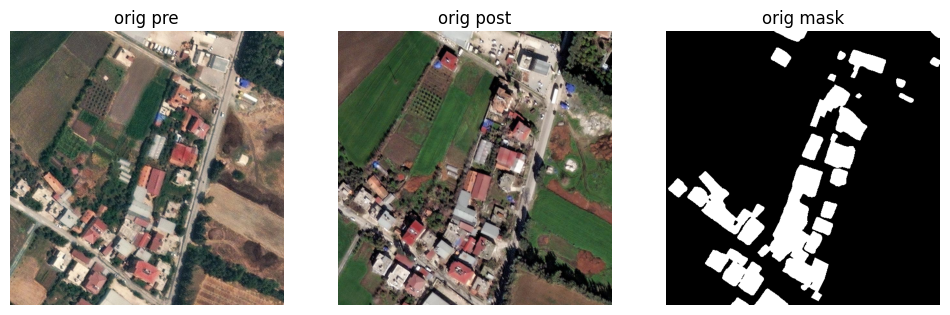

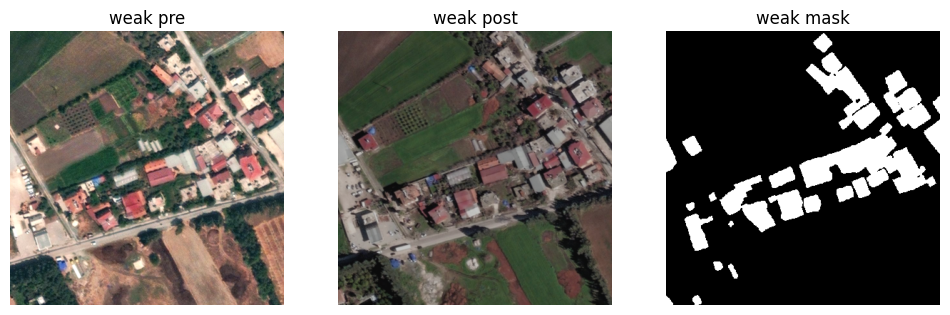

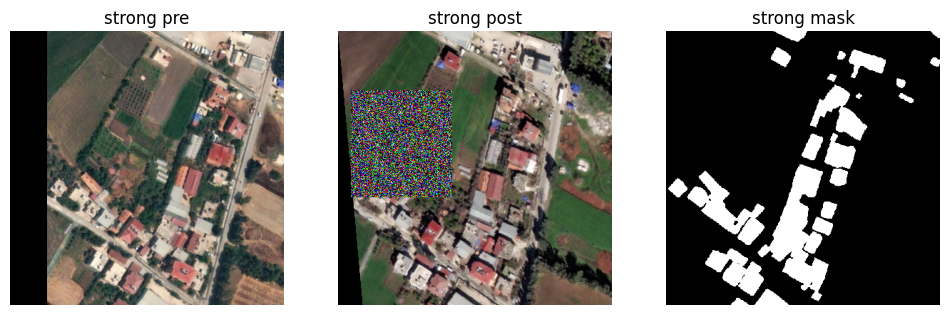

In [ ]:
# ======= Visual test =======
import matplotlib.pyplot as plt
import random
df = pd.read_csv('splits/train.csv')
r = random.choice(df.to_dict('records'))
pre_np = np.array(Image.open(r['pre']).convert('RGB'))
post_np = np.array(Image.open(r['post']).convert('RGB'))
mask_np = np.array(Image.open(r['mask']).convert('L'))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(pre_np); plt.title('orig pre'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(post_np); plt.title('orig post'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(mask_np, cmap='gray'); plt.title('orig mask'); plt.axis('off')

pw, postw, maskw = weak_transform(pre_np, post_np, mask_np, img_size=(384,384))
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(np.transpose(pw.numpy(), (1,2,0))); plt.title('weak pre'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(np.transpose(postw.numpy(), (1,2,0))); plt.title('weak post'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(maskw.numpy(), cmap='gray'); plt.title('weak mask'); plt.axis('off')

ps, posts, masks = strong_transform(pre_np, post_np, mask_np, img_size=(384,384))
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(np.transpose(ps.numpy(), (1,2,0))); plt.title('strong pre'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(np.transpose(posts.numpy(), (1,2,0))); plt.title('strong post'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(masks.numpy(), cmap='gray'); plt.title('strong mask'); plt.axis('off')
plt.show()

## 6) ViT baseline (model)

In [28]:
import timm
import torch.nn as nn
import torch

class ViTBinarySeg(nn.Module):
    def __init__(self, vit_name='vit_base_patch16_384', pretrained=True, use_post_only=False, img_size=384, patch_size=16):
        super().__init__()
        self.use_post_only = use_post_only
        self.vit = timm.create_model(vit_name, pretrained=pretrained, num_classes=0)
        if not use_post_only:
            if hasattr(self.vit, 'patch_embed') and hasattr(self.vit.patch_embed, 'proj'):
                proj = self.vit.patch_embed.proj
                w = proj.weight
                if w.shape[1] == 3:
                    new_w = torch.cat([w, w.clone()], dim=1)
                    proj.weight = nn.Parameter(new_w)
        self.embed_dim = self.vit.embed_dim
        self.linear = nn.Conv2d(self.embed_dim, 256, kernel_size=1)
        self.decoder = nn.Sequential(
            nn.Conv2d(256,128,3,padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128,64,3,padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64,32,3,padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=(patch_size//1), mode='bilinear', align_corners=False),
        )
        self.head = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        B,C,H,W = x.shape
        tokens = self.vit.forward_features(x)
        if tokens.dim() == 3:
            B,N,D = tokens.shape
            h = w = int(N**0.5)
            feat = tokens.transpose(1,2).reshape(B, D, h, w)
        else:
            feat = tokens
        x = self.linear(feat)
        x = self.decoder(x)
        logits = self.head(x)
        if logits.shape[2] != H or logits.shape[3] != W:
            logits = nn.functional.interpolate(logits, size=(H,W), mode='bilinear', align_corners=False)
        return logits

# instantiate
model = ViTBinarySeg(pretrained=True, use_post_only=False)
print('Model ready')

Model ready


## 7) Training skeleton

In [23]:
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
bce = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1.):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    t = targets.view(targets.size(0), -1).float()
    inter = (probs * t).sum(1)
    union = probs.sum(1) + t.sum(1)
    dice = (2*inter + smooth) / (union + smooth)
    return 1 - dice.mean()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for inp, mask in tqdm(loader):
        inp = inp.to(device); mask = mask.to(device).unsqueeze(1).float()
        logits = model(inp)
        loss = bce(logits, mask) + dice_loss(logits, mask)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader):
    model.eval()
    ious=[]
    with torch.no_grad():
        for inp, mask in loader:
            inp = inp.to(device); mask = mask.to(device)
            logits = model(inp)
            preds = (torch.sigmoid(logits) > 0.5).long().squeeze(1)
            inter = ((preds==1) & (mask==1)).sum(dim=(1,2)).float()
            union = ((preds==1) | (mask==1)).sum(dim=(1,2)).float()
            iou = ((inter+1e-6)/(union+1e-6)).mean().item()
            ious.append(iou)
    return float(np.mean(ious)) if len(ious)>0 else 0.0

print('Training utils ready')

Training utils ready


In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF

class PrePostTorchAugDataset(Dataset):
    def __init__(self, csv_path, img_size=(384,384), augment=True, ssl_mode=False, use_post_only=False):
        """
        csv_path: path to CSV file (e.g. splits/train.csv)
        img_size: resize target for all images
        augment: whether to apply data augmentation (True during training)
        ssl_mode: if True, returns weak+strong views (for semi-supervised)
        use_post_only: if True, uses only post-disaster image instead of stacking pre+post
        """
        self.df = pd.read_csv(csv_path)
        self.img_size = img_size
        self.augment = augment
        self.ssl_mode = ssl_mode
        self.use_post_only = use_post_only

    def __len__(self):
        return len(self.df)

    def _load_raw(self, pre_path, post_path, mask_path):
        pre = np.array(Image.open(pre_path).convert('RGB'))
        post = np.array(Image.open(post_path).convert('RGB'))
        mask = np.array(Image.open(mask_path).convert('L'))
        return pre, post, mask

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pre_np, post_np, mask_np = self._load_raw(row['pre'], row['post'], row['mask'])
        from torchvision import transforms
        resize = transforms.Resize(self.img_size)
        pre_img = resize(Image.fromarray(pre_np))
        post_img = resize(Image.fromarray(post_np))
        mask_img = TF.resize(Image.fromarray(mask_np), self.img_size, interpolation=Image.NEAREST)
   
        pre_t = TF.to_tensor(pre_img)
        post_t = TF.to_tensor(post_img)
        mask_t = torch.from_numpy(np.array(mask_img, dtype=np.uint8)).long()
        mask_t = (mask_t > 128).long()  
        if self.use_post_only:
            inp = post_t
        else:
            inp = torch.cat([pre_t, post_t], dim=0)

        if not self.ssl_mode:
            return inp, mask_t
        pre_s, post_s, mask_s = strong_transform(pre_np, post_np, mask_np)
        inp_s = torch.cat([pre_s, post_s], dim=0)
        return inp, inp_s, mask_t

In [ ]:
import timm, torch, torch.nn as nn
import math

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def vit_extract_tokens(vit, x):
    """
    Given a timm ViT model instance (vit) and input tensor x (B,C,H,W),
    return token embeddings of shape (B, N, D) where N = num_patches + 1 (cls token).
    This works even if vit lacks forward_features / features_only.
    """
    if not hasattr(vit, "patch_embed"):
        raise RuntimeError("Backbone has no patch_embed; cannot extract tokens automatically.")

    x_p = vit.patch_embed(x)  =
    if x_p.dim() == 4:
        B, D, Hf, Wf = x_p.shape
        x_tokens = x_p.flatten(2).transpose(1,2)  # B, N, D
    else:
        x_tokens = x_p  # already B, N, D

    B, N, D = x_tokens.shape
    if hasattr(vit, "cls_token"):
        cls_token = vit.cls_token
        try:
            cls_token_exp = cls_token.expand(B, -1, -1)  # (B,1,D)
        except Exception:
            cls_token_exp = cls_token.reshape(1,1,-1).expand(B, -1, -1)
        x_tokens = torch.cat((cls_token_exp.to(x_tokens.dtype).to(x_tokens.device), x_tokens), dim=1)  # B, N+1, D
    if hasattr(vit, "pos_embed"):
        pos = vit.pos_embed
        if pos.shape[1] == x_tokens.shape[1]:
            x_tokens = x_tokens + pos.to(x_tokens.device).to(x_tokens.dtype)
        else:
            pos_tok = pos
            try:
                pos_tok = pos_tok.detach()
                L = pos_tok.shape[1]
                target_L = x_tokens.shape[1]
                if L != target_L:
                    if hasattr(vit, "cls_token"):
                        cls_pos, grid_pos = pos_tok[:, :1], pos_tok[:, 1:]
                        gL = grid_pos.shape[1]
                        gsize = int(math.sqrt(gL))
                        grid_pos = grid_pos.reshape(1, gsize, gsize, -1).permute(0,3,1,2)  
                        new_gsize = int(math.sqrt(target_L - 1))
                        grid_pos_interp = nn.functional.interpolate(grid_pos, size=(new_gsize,new_gsize), mode='bilinear', align_corners=False)
                        grid_pos_interp = grid_pos_interp.permute(0,2,3,1).reshape(1, -1, pos_tok.shape[-1])
                        pos_tok = torch.cat([cls_pos, grid_pos_interp], dim=1)
                        pos_tok = pos_tok.to(x_tokens.device).to(x_tokens.dtype)
                        x_tokens = x_tokens + pos_tok
                    else:
                        grid_pos = pos_tok.reshape(1, int(math.sqrt(L)), int(math.sqrt(L)), -1).permute(0,3,1,2)
                        new_gsize = int(math.sqrt(target_L))
                        grid_pos_interp = nn.functional.interpolate(grid_pos, size=(new_gsize,new_gsize), mode='bilinear', align_corners=False)
                        grid_pos_interp = grid_pos_interp.permute(0,2,3,1).reshape(1, -1, pos_tok.shape[-1])
                        pos_tok = grid_pos_interp.to(x_tokens.device).to(x_tokens.dtype)
                        x_tokens = x_tokens + pos_tok
            except Exception:
                pass

    if hasattr(vit, "pos_drop"):
        x_tokens = vit.pos_drop(x_tokens)
    if hasattr(vit, "blocks"):
        for blk in vit.blocks:
            x_tokens = blk(x_tokens)
    if hasattr(vit, "norm"):
        x_tokens = vit.norm(x_tokens)
    return x_tokens  

class ViTSegFromTokens(nn.Module):
    def __init__(self, vit_model, use_post_only=False, patch_size=16, decoder_channels=256):
        super().__init__()
        self.vit = vit_model
        self.use_post_only = use_post_only
        self.patch_size = patch_size
        self.embed_dim = getattr(self.vit, 'embed_dim', None)
        if self.embed_dim is None and hasattr(self.vit, 'pos_embed'):
            self.embed_dim = int(self.vit.pos_embed.shape[-1])
        if self.embed_dim is None:
            self.embed_dim = 768

        self.proj = nn.Conv2d(self.embed_dim, decoder_channels, kernel_size=1)

        self.decoder = nn.Sequential(
            nn.Conv2d(decoder_channels, 128, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128,64,3,padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64,32,3,padding=1), nn.ReLU(),
        )
        self.head = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        tokens = vit_extract_tokens(self.vit, x) 
        if tokens.shape[1] == 1:
            raise RuntimeError("Only CLS token present after extraction; cannot reshape to spatial.")
        if hasattr(self.vit, "cls_token") and tokens.shape[1] == ( (H//self.patch_size)*(W//self.patch_size) + 1):
            tokens_sp = tokens[:, 1:, :]  # B x N x D
        else:
            tokens_sp = tokens

        B, N, D = tokens_sp.shape
        S = int(math.sqrt(N))
        if S*S != N:
            ph = H // self.patch_size
            pw = W // self.patch_size
            if ph*pw == N:
                S = ph
            else:
                raise RuntimeError(f"Cannot infer spatial shape from N={N}, image HxW={H}x{W} and patch {self.patch_size}")
        feat = tokens_sp.transpose(1,2).reshape(B, D, S, S).contiguous()
        x = self.proj(feat)
        x = self.decoder(x)
        logits = self.head(x)
        logits = nn.functional.interpolate(logits, size=(H, W), mode='bilinear', align_corners=False)
        return logits
backbone = timm.create_model('vit_base_patch16_384', pretrained=True, num_classes=0) 
try:
    proj = backbone.patch_embed.proj
    w = proj.weight
    if w.shape[1] == 3:
        new_w = torch.cat([w, w.clone()], dim=1) 
        proj.weight = nn.Parameter(new_w)
except Exception:
    pass

seg_model = ViTSegFromTokens(backbone, use_post_only=False, patch_size=16).to(device)
seg_model.eval()
print("Rebuilt seg_model from backbone on device:", device)

inp, mask = val_ds[0]
with torch.no_grad():
    out = seg_model(inp.unsqueeze(0).to(device))
print("Forward test output shape:", out.shape)  

Rebuilt seg_model from backbone on device: cpu
Forward test output shape: torch.Size([1, 1, 384, 384])


## 8) Visualization helpers

In [ ]:
import os, tqdm, numpy as np
from PIL import Image

def infer_and_save(model, dataset, out_dir="predictions_val", threshold=0.5, device='cpu'):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()
    results = []
    with torch.no_grad():
        for idx in tqdm.tqdm(range(len(dataset)), desc="Infer"):
            sample = dataset[idx]   # dataset returns (inp, mask)
            if isinstance(sample, tuple) and len(sample) >= 1:
                inp = sample[0]
            else:
                inp = sample
            inp = inp.unsqueeze(0).to(device)  # 1xCxHxW
            logits = model(inp)                # 1x1xH xW
            probs = torch.sigmoid(logits).squeeze().cpu().numpy()  # HxW
            pred_mask = (probs > threshold).astype(np.uint8)

            post_path = dataset.df.iloc[idx]['post']
            post = np.array(Image.open(post_path).convert('RGB').resize(pred_mask.shape[::-1]))
            overlay = post.copy()
            overlay[pred_mask==1] = [255,0,0]
            blended = ((0.6*post + 0.4*overlay).astype(np.uint8))

            out_name = os.path.basename(post_path).replace('.png','_pred_overlay.png')
            out_path = os.path.join(out_dir, out_name)
            Image.fromarray(blended).save(out_path)
            results.append((post_path, out_path))
    return results

device = 'cuda' if torch.cuda.is_available() else 'cpu'
preds = infer_and_save(seg_model, val_ds, out_dir='predictions_val', threshold=0.5, device=device)
print("Saved overlays:", len(preds))

Infer: 100%|██████████| 189/189 [03:45<00:00,  1.19s/it]

Saved overlays: 189


In [ ]:
import numpy as np
from PIL import Image
def compute_metrics_on_dataset(model, dataset, threshold=0.5, device='cpu', max_samples=None):
    model.eval()
    ious = []; dices = []; precisions = []; recalls = []
    cnt = 0
    with torch.no_grad():
        for idx in range(len(dataset)):
            if max_samples and cnt >= max_samples: break
            inp, mask = dataset[idx]   
            inp = inp.unsqueeze(0).to(device)
            logits = model(inp)
            probs = torch.sigmoid(logits).squeeze().cpu().numpy()
            pred = (probs > threshold).astype(np.uint8)
            true = np.array(mask).astype(np.uint8)
            if pred.shape != true.shape:
                true = np.array(Image.fromarray((true*255).astype('uint8')).resize(pred.shape[::-1], resample=Image.NEAREST))//255
            tp = np.logical_and(pred==1, true==1).sum()
            fp = np.logical_and(pred==1, true==0).sum()
            fn = np.logical_and(pred==0, true==1).sum()
            union = tp + fp + fn
            iou = (tp / union) if union>0 else 1.0
            dice = (2*tp / (2*tp + fp + fn)) if (2*tp + fp + fn)>0 else 1.0
            prec = tp / (tp + fp) if (tp + fp)>0 else 1.0
            rec = tp / (tp + fn) if (tp + fn)>0 else 1.0
            ious.append(iou); dices.append(dice); precisions.append(prec); recalls.append(rec)
            cnt += 1
    return {
        "mean_iou": float(np.mean(ious)),
        "mean_dice": float(np.mean(dices)),
        "mean_precision": float(np.mean(precisions)),
        "mean_recall": float(np.mean(recalls)),
        "n": cnt
    }

device = 'cuda' if torch.cuda.is_available() else 'cpu'
metrics = compute_metrics_on_dataset(seg_model, val_ds, threshold=0.5, device=device)
print(metrics)

C:\Users\Asus\AppData\Local\Temp\ipykernel_26644\4194033383.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  true = np.array(mask).astype(np.uint8)


{'mean_iou': 0.038354608419802, 'mean_dice': 0.06853621235343817, 'mean_precision': 0.1545975760895133, 'mean_recall': 0.15955217001432287, 'n': 189}


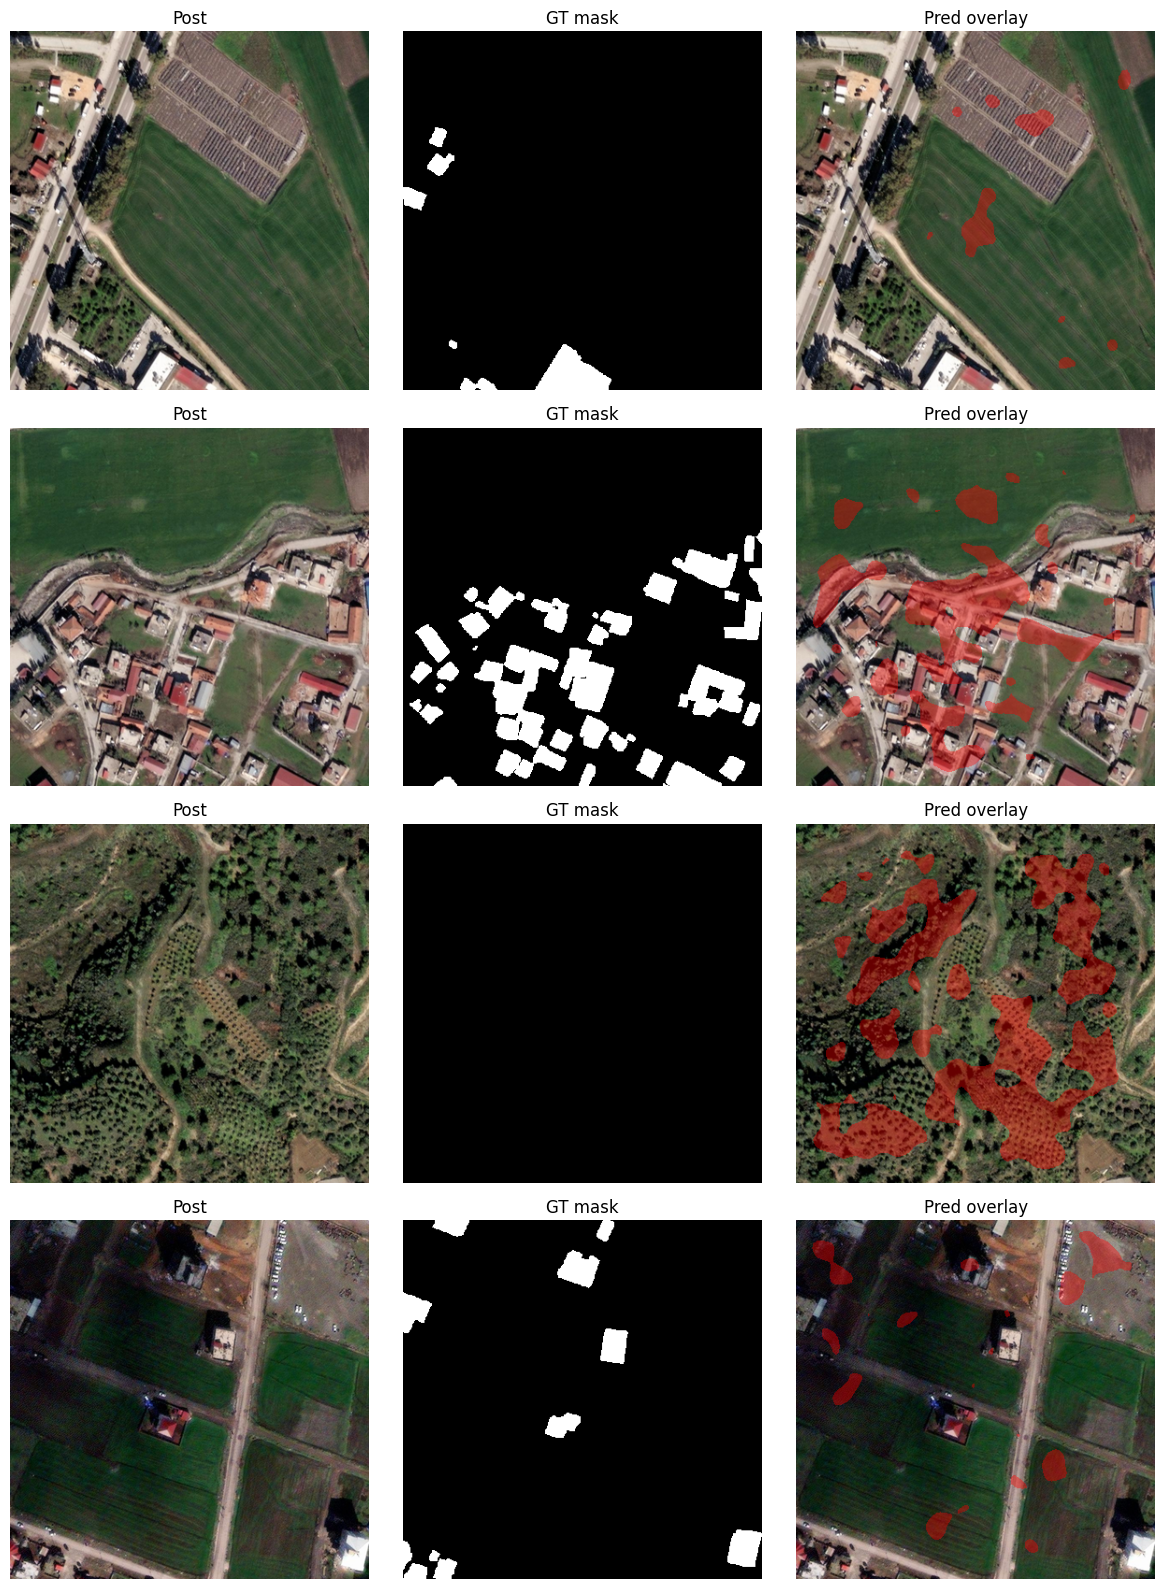

In [ ]:
import matplotlib.pyplot as plt
def visualize_predictions_grid(model, dataset, indices=[0,5,10], threshold=0.5, device='cpu'):
    model.eval()
    n = len(indices)
    cols = 3
    plt.figure(figsize=(12,4*n))
    for i, idx in enumerate(indices):
        inp, mask = dataset[idx]
        inp_b = inp.unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(inp_b)
            probs = torch.sigmoid(logits).squeeze().cpu().numpy()
        pred = (probs > threshold).astype(np.uint8)
        post_path = dataset.df.iloc[idx]['post']
        post = np.array(Image.open(post_path).convert('RGB').resize(pred.shape[::-1]))
        
        plt.subplot(n, cols, i*cols + 1); plt.imshow(post); plt.title("Post"); plt.axis('off')
        plt.subplot(n, cols, i*cols + 2); plt.imshow(mask, cmap='gray'); plt.title("GT mask"); plt.axis('off')
        blended = ((0.6*post + 0.4*(np.where(pred[...,None]==1,[255,0,0],post))).astype(np.uint8))
        plt.subplot(n, cols, i*cols + 3); plt.imshow(blended); plt.title("Pred overlay"); plt.axis('off')
    plt.tight_layout()
    plt.show()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
visualize_predictions_grid(seg_model, val_ds, indices=[0,5,10,20], threshold=0.5, device=device)